### Week 1

#### Project Description

This project investigates factors associated with chronic diseases using publicly available healthcare datasets. The diabetes dataset contains demographic, behavioral, and health-related indicators, while the Alzheimer’s dataset contains patient characteristics associated with cognitive decline. The goal is to explore relationships among variables and evaluate how regression techniques can model outcomes of interest.

In [5]:
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd

diabetes = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
alz = pd.read_csv("alzheimers_disease_data.csv")

print(diabetes.shape)
print(alz.shape)
print(diabetes.columns.tolist())

(253680, 22)
(2149, 35)
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [10]:
diabetes.head()
diabetes.describe()
diabetes.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

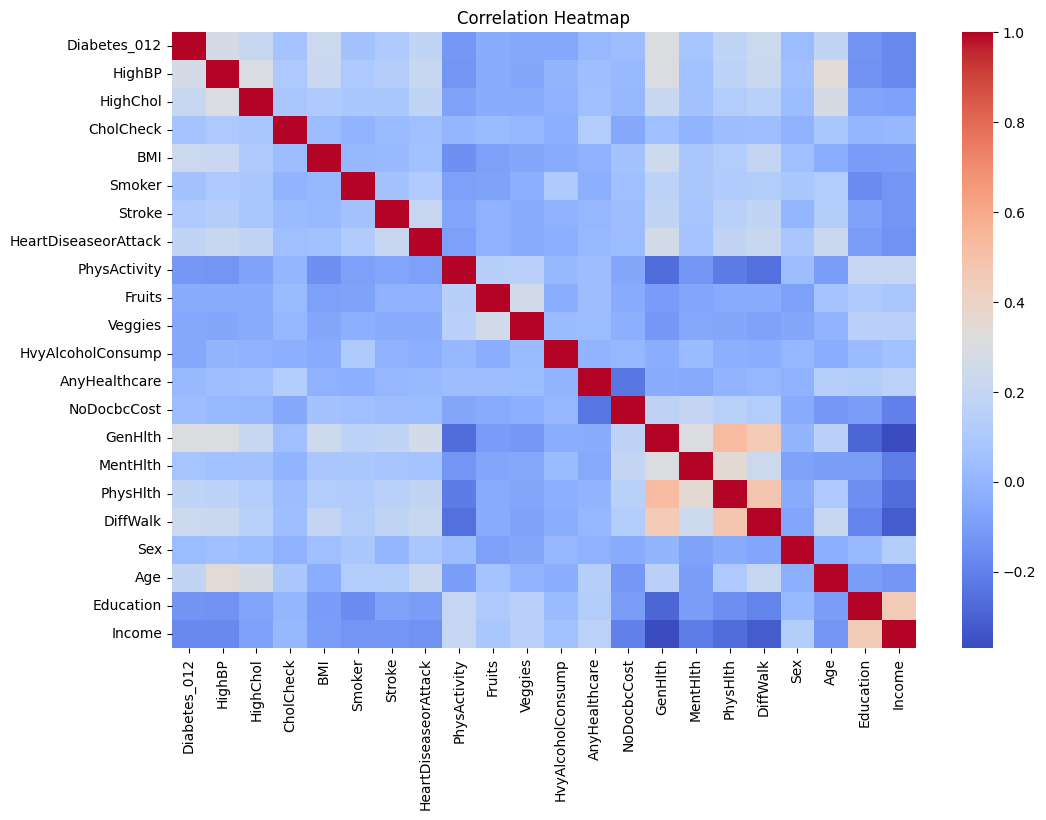

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(diabetes.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##### Exploratory Data Analysis

The diabetes dataset contains 253,680 observations and 22 variables related to health behaviors, demographics, and medical conditions. No missing values were present in the dataset, allowing all observations to be used in modeling. The correlation heatmap revealed several moderate relationships among variables, particularly between general health, physical health, and difficulty walking. These findings suggest that some predictors may exhibit multicollinearity and warrant further investigation.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X = diabetes.drop("Diabetes_012", axis=1)
y = diabetes["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("R²:", r2_score(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

R²: 0.17330978646059458
RMSE: 0.6322608048598488


##### Baseline Linear Regression

A linear regression model was developed to predict diabetes status using the available health indicators. The model achieved an R² value of 0.173 and an RMSE of 0.632. While the model explained a modest portion of the variation in diabetes status, several predictors showed meaningful relationships with the target variable. High blood pressure, heart disease, high cholesterol, and poor general health were among the strongest positive predictors.

In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
0,HighBP,0.154034
6,HeartDiseaseorAttack,0.137241
1,HighChol,0.116211
13,GenHlth,0.097865
2,CholCheck,0.096010
16,DiffWalk,0.095368
5,Stroke,0.073872
17,Sex,0.034485
11,AnyHealthcare,0.026260
18,Age,0.016034


In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_poly = poly.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train_poly)

poly_preds = poly_model.predict(X_test_poly)

print(
    "Polynomial R²:",
    r2_score(y_test_poly, poly_preds)
)

print(
    "Polynomial RMSE:",
    np.sqrt(mean_squared_error(y_test_poly, poly_preds))
)

Polynomial R²: 0.20258668422985748
Polynomial RMSE: 0.6209642580080668


##### Polynomial Regression

Polynomial features were introduced to capture nonlinear relationships between predictors and diabetes status. The polynomial model improved performance, increasing R² from 0.173 to 0.203 and reducing RMSE from 0.632 to 0.621. This suggests that some relationships between health indicators and diabetes status are not strictly linear.

In [15]:
diabetes["Age_GenHlth"] = diabetes["Age"] * diabetes["GenHlth"]

X_interaction = diabetes.drop("Diabetes_012", axis=1)
y = diabetes["Diabetes_012"]

X_train, X_test, y_train, y_test = train_test_split(
    X_interaction,
    y,
    test_size=0.2,
    random_state=42
)

interaction_model = LinearRegression()

interaction_model.fit(X_train, y_train)

interaction_preds = interaction_model.predict(X_test)

print(
    "Interaction R²:",
    r2_score(y_test, interaction_preds)
)

print(
    "Interaction RMSE:",
    np.sqrt(mean_squared_error(y_test, interaction_preds))
)

Interaction R²: 0.17583254942822568
Interaction RMSE: 0.6312953507788398


##### Interaction Terms

An interaction term between Age and General Health was added to evaluate whether the effect of age on diabetes status changes depending on an individual’s overall health. The model achieved an R² of 0.176 and an RMSE of 0.631. While the interaction term produced a slight improvement over the baseline model, the improvement was substantially smaller than that observed with polynomial features.

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(X)

vif_df = pd.DataFrame()

vif_df["Feature"] = X_vif.columns

vif_df["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_df.sort_values(
    "VIF",
    ascending=False
)

,Feature,VIF
0,const,115.971455
14,GenHlth,1.795892
16,PhysHlth,1.623288
17,DiffWalk,1.533902
21,Income,1.503931
19,Age,1.349994
1,HighBP,1.330684
20,Education,1.326390
15,MentHlth,1.239297
2,HighChol,1.173313


### Week 1 Conclusion Section
##### Conclusions

This analysis applied linear regression, polynomial regression, interaction terms, and multicollinearity diagnostics to a diabetes dataset containing 253,680 observations. The baseline linear regression model achieved an R² of 0.173, indicating that several health indicators are associated with diabetes status. High blood pressure, heart disease, high cholesterol, and poor general health emerged as the strongest positive predictors.

Polynomial regression improved model performance, increasing R² to 0.203 and reducing RMSE from 0.632 to 0.621. This suggests that nonlinear relationships exist among the predictors and diabetes status. An interaction term between age and general health produced only a small improvement over the baseline model, indicating that this specific interaction contributes limited additional explanatory power.

VIF analysis showed very low levels of multicollinearity, with all predictor variables having VIF values below 2. This indicates that the predictors provide largely unique information and that coefficient estimates are relatively stable. Overall, the findings suggest that diabetes status is influenced by multiple health-related factors and that more advanced modeling techniques may further improve predictive performance.